In [ ]:
sample_lyrics_path = "/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/FooFighters - Everlong.txt"
sample_song_path = "/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/Foo Fighters - Everlong (Official HD Video).mp3"
sample_metadata = {
    "track": "Everlong",
    "artist": "Foo Fighters",
    "key": "A Major",
    "bpm": "173",
    "duration": "4:10",
    "camelot": "11B",
    "acousticness": "0.000917",
    "danceability": "0.433",
    "energy": "10",
    "instrumentalness": "0.0",
    "liveness": "0.028",
    "loudness": "-4.04",
    "speechiness": "0.0431",
    "valence": "0.365",
    "popularity": "84",
    "release_date": "1997-05-20",
    "track_url": "https://songdata.io/track/5UWwZ5lm5PKu6eKsHAGxOk/Everlong-by-Foo-Fighters"
  }

In [1]:
# create a dummy dataframe with the sample metadata, lyrics, and song path:

import pandas as pd

# Create a DataFrame with the sample metadata
df = pd.DataFrame({
    "track": [sample_metadata["track"]],
    "artist": [sample_metadata["artist"]],
    "key": [sample_metadata["key"]],
    "bpm": [sample_metadata["bpm"]],
    "duration": [sample_metadata["duration"]],
    "camelot": [sample_metadata["camelot"]],
    "acousticness": [sample_metadata["acousticness"]],
    "danceability": [sample_metadata["danceability"]],
    "energy": [sample_metadata["energy"]],
    "instrumentalness": [sample_metadata["instrumentalness"]],
    "liveness": [sample_metadata["liveness"]],
    "loudness": [sample_metadata["loudness"]],
    "speechiness": [sample_metadata["speechiness"]],
    "valence": [sample_metadata["valence"]],
    "popularity": [sample_metadata["popularity"]],
    "release_date": [sample_metadata["release_date"]],
    "track_url": [sample_metadata["track_url"]],
    "lyrics_path": [sample_lyrics_path],
    "song_path": [sample_song_path]
})
# Save the DataFrame to a CSV file
df.to_csv("sample_dataset.csv", index=False)

NameError: name 'sample_metadata' is not defined

In [ ]:
sample_df = pd.read_csv("sample_dataset.csv")

In [ ]:
sample_df.head()

,track,artist,key,bpm,duration,camelot,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,popularity,release_date,track_url,lyrics_path,song_path
0,Everlong,Foo Fighters,A Major,173,4:10,11B,0.000917,0.433,10,0.0,0.028,-4.04,0.0431,0.365,84,1997-05-20,https://songdata.io/track/5UWwZ5lm5PKu6eKsHAGx...,/home/psyph3ri0n/Documents/projects-2025/sur/f...,/home/psyph3ri0n/Documents/projects-2025/sur/f...


In [ ]:
# remove track_url and lyrics_path columns
sample_df = sample_df.drop(columns=["track_url"])

sample_df.head()

,track,artist,key,bpm,duration,camelot,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,popularity,release_date,lyrics_path,song_path
0,Everlong,Foo Fighters,A Major,173,4:10,11B,0.000917,0.433,10,0.0,0.028,-4.04,0.0431,0.365,84,1997-05-20,/home/psyph3ri0n/Documents/projects-2025/sur/f...,/home/psyph3ri0n/Documents/projects-2025/sur/f...


In [ ]:
# foreach row get the lyrics_path and read the file from the text file
def read_lyrics_from_file(row):
    with open(row["lyrics_path"], "r") as file:
        lyrics = file.read()
    return lyrics
# apply the function to the dataframe
sample_df["lyrics"] = sample_df.apply(read_lyrics_from_file, axis=1)
# remove the lyrics_path column
sample_df = sample_df.drop(columns=["lyrics_path"])

In [ ]:
sample_df.head()

,track,artist,key,bpm,duration,camelot,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,popularity,release_date,song_path,lyrics
0,Everlong,Foo Fighters,A Major,173,4:10,11B,0.000917,0.433,10,0.0,0.028,-4.04,0.0431,0.365,84,1997-05-20,/home/psyph3ri0n/Documents/projects-2025/sur/f...,Hello<br>\nI've waited here for you<br>\nEverl...


In [ ]:
# clean the lyrics content by removing <br> tags and new lines and turing caps to lower
def clean_lyrics(lyrics):
    # Remove <br> tags and new lines
    lyrics = lyrics.replace("<br>", " ").replace("\n", " ")
    # Convert to lowercase
    lyrics = lyrics.lower()
    return lyrics
# apply the function to the dataframe
sample_df["lyrics"] = sample_df["lyrics"].apply(clean_lyrics)

In [ ]:
sample_df.head()

,track,artist,key,bpm,duration,camelot,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,popularity,release_date,song_path,lyrics
0,Everlong,Foo Fighters,A Major,173,4:10,11B,0.000917,0.433,10,0.0,0.028,-4.04,0.0431,0.365,84,1997-05-20,/home/psyph3ri0n/Documents/projects-2025/sur/f...,hello i've waited here for you everlong ton...


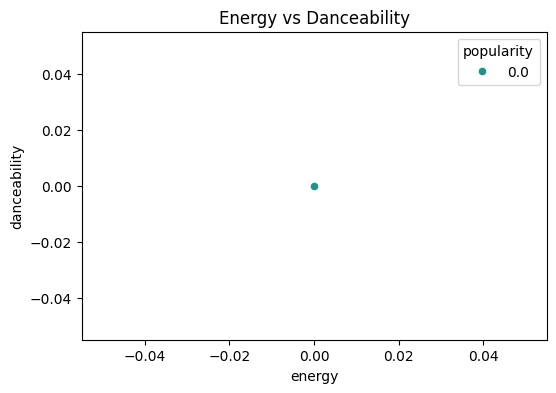

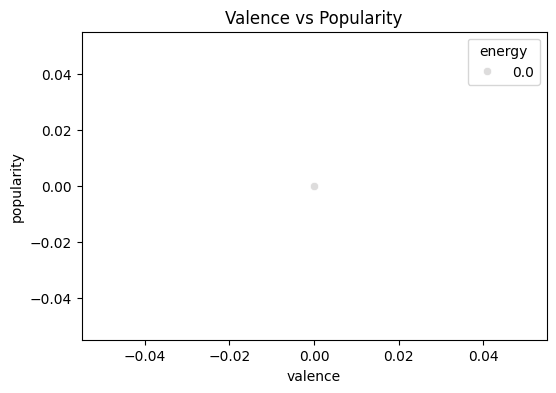

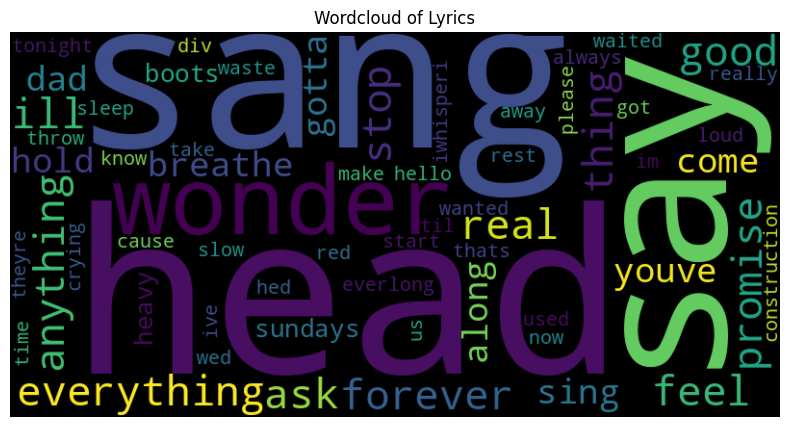

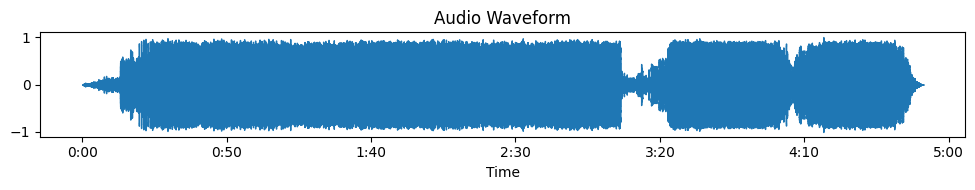

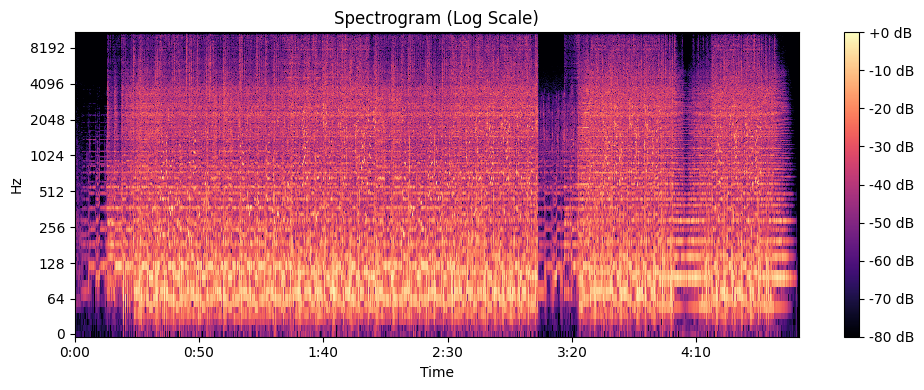

,track,artist,key,bpm,duration,camelot,acousticness,danceability,energy,instrumentalness,...,speechiness,valence,popularity,release_date,song_path,lyrics,duration_sec,camelot_number,camelot_mode,clean_lyrics
0,Everlong,Foo Fighters,A Major,0.0,4:10,11B,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1997-05-20,/home/psyph3ri0n/Documents/projects-2025/sur/f...,hello i've waited here for you everlong ton...,0.0,11,B,hello ive waited here for you everlong tonight...


In [ ]:
# Patch for librosa compatibility with newer NumPy versions
import numpy as np
np.complex = complex  # Patch deprecated usage in librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import librosa
import librosa.display
import re
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
# Re-import librosa now that patch is in place
import librosa
import librosa.display

# Reload the dataset
df = sample_df.copy()

# Duration conversion
def duration_to_seconds(duration_str):
    try:
        minutes, seconds = map(int, duration_str.split(':'))
        return minutes * 60 + seconds
    except:
        return np.nan

df['bpm'] = pd.to_numeric(df['bpm'], errors='coerce')
df['duration_sec'] = df['duration'].apply(duration_to_seconds)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Camelot parsing
def camelot_to_numeric(camelot):
    try:
        number = int(camelot[:-1])
        mode = camelot[-1]
        return pd.Series([number, mode])
    except:
        return pd.Series([np.nan, np.nan])

df[['camelot_number', 'camelot_mode']] = df['camelot'].apply(camelot_to_numeric)

# Normalize selected features
numeric_features = ['bpm', 'duration_sec', 'acousticness', 'danceability', 'energy',
                    'instrumentalness', 'liveness', 'loudness', 'speechiness',
                    'valence', 'popularity']

scaler = MinMaxScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Lyrics cleanup
def clean_lyrics(lyric):
    lyric = str(lyric).lower()
    lyric = re.sub(r'[^a-z\s]', '', lyric)
    lyric = re.sub(r'\s+', ' ', lyric).strip()
    return lyric

df['clean_lyrics'] = df['lyrics'].apply(clean_lyrics)

# Visuals
# Energy vs Danceability
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='energy', y='danceability', hue='popularity', palette='viridis')
plt.title('Energy vs Danceability')
plt.show()

# Popularity vs Valence
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='valence', y='popularity', hue='energy', palette='coolwarm')
plt.title('Valence vs Popularity')
plt.show()

# Wordcloud
text = ' '.join(df['clean_lyrics'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud of Lyrics')
plt.show()

# Load audio and plot waveform + spectrogram
audio_path = df['song_path'].iloc[0]
y, sr = librosa.load(audio_path, sr=22050)

# Waveform
plt.figure(figsize=(10, 2))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.tight_layout()
plt.show()

# Spectrogram
plt.figure(figsize=(10, 4))
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (Log Scale)')
plt.tight_layout()
plt.show()

df.head()


In [ ]:
import os

song_paths = os.listdir("/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/")
# add original path using os.path.join and os.cwd
song_paths = [os.path.join("/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/", path) for path in song_paths]
# Filter out non-MP3 files
song_paths = [path for path in song_paths if path.endswith('.mp3')]

with open("song_paths.txt", "w") as f:
    for path in song_paths:
        f.write(path + "\n")


lyrics_paths = os.listdir("/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/")
# Filter out non-text files
lyrics_paths = [path for path in lyrics_paths if path.endswith('.txt')]
# add original path using os.path.join and os.cwd
lyrics_paths = [os.path.join("/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/", path) for path in lyrics_paths]

with open("lyrics_paths.txt", "w") as f:
    for path in lyrics_paths:
        f.write(path + "\n")


In [ ]:
import os
import re
from difflib import get_close_matches

# Load from saved paths
with open("song_paths.txt", "r") as f:
    song_paths = [line.strip() for line in f.readlines()]

with open("lyrics_paths.txt", "r") as f:
    lyrics_paths = [line.strip() for line in f.readlines()]

# Function to normalize filenames
def normalize(name):
    name = re.sub(r'\(.*?\)|\[.*?\]', '', name)  # Remove text in brackets
    name = re.sub(r'official|video|audio|remaster|hd|lyric', '', name, flags=re.IGNORECASE)
    name = re.sub(r'[^a-zA-Z0-9 ]', '', name).lower().strip()
    name = re.sub(r'\s+', ' ', name)
    return name

# Normalize both sets
norm_songs = {normalize(song): song for song in song_paths}
norm_lyrics = {normalize(lyric.replace('.txt', '')): lyric for lyric in lyrics_paths}

# Mapping logic
mapping = {}
for norm_song, orig_song in norm_songs.items():
    match = get_close_matches(norm_song, norm_lyrics.keys(), n=1, cutoff=0.6)
    if match:
        mapping[orig_song] = norm_lyrics[match[0]]
    else:
        mapping[orig_song] = None  # No match found

# Print mapped pairs
for song_file, lyrics_file in mapping.items():
    print(f"{song_file} --> {lyrics_file if lyrics_file else '❌ No match'}")

# Save the mapping to a CSV file
import pandas as pd
mapping_df = pd.DataFrame(mapping.items(), columns=['song_path', 'lyrics_path'])
mapping_df.to_csv("song_lyrics_mapping.csv", index=False)
# Load the mapping CSV
mapping_df = pd.read_csv("song_lyrics_mapping.csv")


/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/The Kinks - All Day And All Of The Night (Official Audio).mp3 --> /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/Kinks - AllDayandAlloftheNight.txt
/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/The Rolling Stones - Gimme Shelter (Official Lyric Video).mp3 --> /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/RollingStones - GimmeShelter.txt
/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/Nirvana - Something In The Way (Audio).mp3 --> /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/Nirvana - Lithium.txt
/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/505.mp3 --> /home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics/aha - TakeonMe.txt
/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/dow

In [ ]:
import json
import os
import pandas as pd
from difflib import get_close_matches

# 1. Load the playlist metadata
with open("/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json", "r") as f:
    playlist_data = json.load(f)

# 2. Load audio/lyrics mapping
mapping = {}
with open("/home/psyph3ri0n/Documents/projects-2025/sur/exploration/song_lyrics_mapping.csv", "r") as f:
    next(f)  # skip header
    for line in f:
        audio, lyrics = line.strip().split(",")
        mapping[os.path.basename(audio)] = {
            "audio_path": audio,
            "lyrics_path": lyrics if lyrics else None
        }

# 3. Normalize function for fuzzy matching
def normalize(name):
    return ''.join(e for e in name.lower() if e.isalnum())

# 4. Build the final structured dataset
final_records = []

for song in playlist_data:
    track = song["track"]
    artist = song["artist"]
    song_id = f"{artist} - {track}"
    song_id_norm = normalize(song_id)

    # Try to find matching audio file from mapping using fuzzy match
    candidates = [normalize(k) for k in mapping.keys()]
    match = get_close_matches(song_id_norm, candidates, n=1, cutoff=0.7)

    if match:
        matched_filename = [k for k in mapping.keys() if normalize(k) == match[0]][0]
        entry = {
            **song,
            "audio_path": mapping[matched_filename]["audio_path"],
            "lyrics_path": mapping[matched_filename]["lyrics_path"]
        }
        final_records.append(entry)
    else:
        print(f"⚠️ No match for {song_id}")

# 5. Save as CSV or DataFrame
df = pd.DataFrame(final_records)
df.to_csv("structured_playlist_data.csv", index=False)


ValueError: too many values to unpack (expected 2)

In [2]:
import os
import re
import csv
import json
import pandas as pd
from fuzzywuzzy import process, fuzz

# === CONFIGURATION ===
PLAYLIST_JSON = "/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json"
MAPPING_CSV = "/home/psyph3ri0n/Documents/projects-2025/sur/exploration/song_lyrics_mapping.csv"
OUTPUT_CSV = "structured_playlist_data_v2.csv" # Use a new output file name
MATCH_THRESHOLD = 75 # Lowered threshold slightly, adjust as needed

# === TITLE NORMALIZATION & ALIAS GENERATION ===
def normalize_name(name):
    name = name.lower()
    # More aggressive removal of bracketed/parenthesized content
    name = re.sub(r"[\(\[].*?[\)\]]", "", name)
    # Remove common separators and keywords BEFORE removing non-alphanumeric
    name = name.replace('-', ' ').replace('–', ' ') # Replace hyphens with spaces
    name = re.sub(r"\b(remaster(ed)?\s?(\d{4})?)\b", "", name)
    name = re.sub(r"\b(official|audio|video|version|live|edit|mono|stereo|album|single|mix|pt|part)\b", "", name)
    name = re.sub(r"\b\d{4}\b", "", name) # Remove standalone 4-digit years
    # Keep basic alphanumeric and spaces
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

def generate_alias(raw_title, is_filename=False):
    """Generates alias. If it's a filename, we don't expect an artist prefix."""
    # Basic normalization first
    base = normalize_name(raw_title)
    # Further cleaning specific to aliases can happen here if needed
    # Example: remove track numbers if they appear like '01 song title'
    base = re.sub(r"^\d+\s+", "", base).strip()
    return base

# === LOAD MAPPING CSV ===
print("Loading mapping CSV...")
mapping = {}
alias_map = {}  # alias → original_filename

try:
    with open(MAPPING_CSV, "r", newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            try:
                # Check if essential columns exist and are not empty
                if not row.get("song_path") or not row.get("lyrics_path"):
                    print(f"⚠️ Skipping row {i+1} due to missing 'song_path' or 'lyrics_path': {row}")
                    continue

                filename = os.path.basename(row["song_path"])
                if not filename:
                     print(f"⚠️ Skipping row {i+1} due to empty filename derived from 'song_path': {row['song_path']}")
                     continue

                song_title_from_file = os.path.splitext(filename)[0]  # strip .mp3
                alias = generate_alias(song_title_from_file, is_filename=True)

                # Handle potential duplicate aliases from filenames (less likely but possible)
                if alias in alias_map:
                    print(f"⚠️ Duplicate alias '{alias}' generated for filenames: '{filename}' and '{alias_map[alias]}'. Keeping the first one.")
                else:
                    alias_map[alias] = filename

                mapping[filename] = {
                    "audio_path": row["song_path"],
                    "lyrics_path": row["lyrics_path"] # Keep the path as is, user needs to verify it
                }
            except Exception as e:
                print(f"🚨 Error processing row {i+1}: {row}")
                print(f"   Error: {e}")
                continue # Skip problematic rows

except FileNotFoundError:
    print(f"🚨 ERROR: Mapping CSV not found at '{MAPPING_CSV}'")
    exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to read or process mapping CSV: {e}")
    exit()

if not alias_map:
    print("🚨 ERROR: No valid entries loaded from the mapping CSV. Cannot proceed.")
    exit()

# === BUILD MAPPING MATCH LIST ===
alias_list = list(alias_map.keys())
print(f"Loaded {len(alias_list)} unique aliases from mapping file.")

# === LOAD PLAYLIST ===
print("Loading playlist JSON...")
try:
    with open(PLAYLIST_JSON, "r") as f:
        playlist_data = json.load(f)
except FileNotFoundError:
    print(f"🚨 ERROR: Playlist JSON not found at '{PLAYLIST_JSON}'")
    exit()
except json.JSONDecodeError:
     print(f"🚨 ERROR: Playlist JSON at '{PLAYLIST_JSON}' is not valid JSON.")
     exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to load playlist JSON: {e}")
    exit()

# === MATCHING LOOP ===
print("Starting matching process...")
final_records = []
unmatched_records = []

for i, song in enumerate(playlist_data):
    # Validate playlist entry structure
    if not song or not song.get("track") or not song.get("artist"):
        print(f"⚠️ Skipping playlist item {i+1} due to missing 'track' or 'artist': {song}")
        continue

    track = song["track"]
    artist = song["artist"]

    combined_title = f"{artist} {track}"
    playlist_alias = generate_alias(combined_title, is_filename=False)

    # Use token_set_ratio and the adjusted threshold
    # process.extractOne returns (best_match_alias, score, index_in_alias_list)
    # We pass alias_list which contains aliases derived from filenames
    result = process.extractOne(playlist_alias, alias_list, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)

    if result:
        best_match_alias, score = result[0], result[1] # Extract alias and score
        matched_filename = alias_map[best_match_alias]
        if matched_filename in mapping:
            entry = {
                **song, # Include all original playlist data
                "audio_path": mapping[matched_filename]["audio_path"],
                "lyrics_path": mapping[matched_filename]["lyrics_path"],
                "match_score": score,
                "matched_filename_alias": best_match_alias,
                "playlist_alias": playlist_alias
            }
            final_records.append(entry)
            # Optional: Print successful matches for verification
            # print(f"✅ Match: '{combined_title}' -> '{matched_filename}' (Score: {score})")
        else:
            # This case should theoretically not happen if alias_map is built correctly from mapping
             print(f"INTERNAL ERROR: Matched alias '{best_match_alias}' not found in mapping keys for '{combined_title}'.")
             unmatched_records.append({**song, "reason": "Internal mapping consistency error"})
    else:
        # No match found above the threshold
        # For debugging, find the best match regardless of score to see how close it was
        best_guess, best_score = process.extractOne(playlist_alias, alias_list, scorer=fuzz.token_set_ratio) or (None, 0)
        print(f"⚠️ No match for: {artist} - {track} [Best guess: '{alias_map.get(best_guess, 'N/A')}' (alias: '{best_guess}') with score={best_score}] [Playlist Alias: '{playlist_alias}']")
        unmatched_records.append({**song, "reason": f"Score below threshold {MATCH_THRESHOLD}", "best_guess_score": best_score, "best_guess_alias": best_guess, "playlist_alias": playlist_alias})


# === SAVE FINAL OUTPUT ===
print("\nSaving results...")
if final_records:
    df_matched = pd.DataFrame(final_records)
    # Reorder columns for clarity
    cols_order = ['artist', 'track', 'match_score', 'audio_path', 'lyrics_path', 'playlist_alias', 'matched_filename_alias']
    # Add any other columns from the original JSON that you want to keep
    original_cols = [col for col in df_matched.columns if col not in cols_order]
    df_matched = df_matched[cols_order + original_cols]
    df_matched.to_csv(OUTPUT_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"✅ Matched dataset ({len(df_matched)} records) saved to: {OUTPUT_CSV}")
else:
    print("No matched records to save.")

# Optionally save unmatched records for review
if unmatched_records:
    UNMATCHED_CSV = "unmatched_playlist_data_v2.csv"
    df_unmatched = pd.DataFrame(unmatched_records)
    df_unmatched.to_csv(UNMATCHED_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"ℹ️ Unmatched dataset ({len(df_unmatched)} records) saved to: {UNMATCHED_CSV}")

print("\n--- IMPORTANT REMINDER ---")
print("⚠️ Please manually verify the 'lyrics_path' column in your source mapping CSV.")
print("   The matching process links playlist entries to audio files based on titles,")
print("   but it relies on the accuracy of the lyrics paths provided in your mapping CSV.")
print("   Several examples provided earlier suggest potential inaccuracies in that file.")
print("---")

/home/psyph3ri0n/Documents/projects-2025/sur/venv/lib/python3.11/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Loading mapping CSV...
Loaded 97 unique aliases from mapping file.
Loading playlist JSON...
Starting matching process...
⚠️ No match for: Guns N' Roses - Welcome To The Jungle [Best guess: 'The Black Crowes - She Talks To Angels (Official Video).mp3' (alias: 'the black crowes she talks to angels') with score=54] [Playlist Alias: 'guns n roses welcome to the jungle']
⚠️ No match for: Led Zeppelin - Whole Lotta Love - 1990 Remaster [Best guess: 'Led Zeppelin - Houses of the Holy (Remaster) [Official Full Album].mp3' (alias: 'led zeppelin houses of the holy') with score=59] [Playlist Alias: 'led zeppelin whole lotta love']
⚠️ No match for: Fleetwood Mac - Dreams - 2004 Remaster [Best guess: 'Sweet Dreams (Are Made of This) (2005 Remaster).mp3' (alias: 'sweet dreams') with score=67] [Playlist Alias: 'fleetwood mac dreams']
⚠️ No match for: David Bowie - Starman - 2012 Remaster [Best guess: 'Bon Jovi - Wanted Dead Or Alive (Official Music Video).mp3' (alias: 'bon jovi wanted dead or alive')

In [5]:
import os
import re
import csv
import json
import pandas as pd
from fuzzywuzzy import process, fuzz
from unidecode import unidecode # Handles accents like ö, ü -> o, u

# === CONFIGURATION ===
PLAYLIST_JSON = "/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json"
MAPPING_CSV = "/home/psyph3ri0n/Documents/projects-2025/sur/exploration/song_lyrics_mapping.csv"
OUTPUT_CSV = "structured_playlist_data_v3.csv" # New output file
UNMATCHED_CSV = "unmatched_playlist_data_v3.csv" # New unmatched file
MATCH_THRESHOLD = 68 # Lowered threshold more, adjust if needed (65-75 range)

# === TITLE NORMALIZATION & ALIAS GENERATION (More Aggressive) ===
def generate_alias_v3(raw_title):
    if not isinstance(raw_title, str):
        return "" # Handle potential non-string inputs

    name = unidecode(raw_title.lower()) # Normalize accents early

    # Remove content within brackets/parentheses more reliably
    name = re.sub(r"[\(\[].*?[\)\]]", "", name)

    # Replace common separators with spaces BEFORE removing non-alphanumeric
    name = name.replace('-', ' ').replace('–', ' ').replace('/', ' ').replace('&', 'and')

    # Remove common keywords and patterns (order matters slightly)
    keywords_to_remove = [
        r'\bremaster(ed)?\s?(\d{4})?\b', r'\banniversary\s?(version|mix)?\b',
        r'\b(official|audio|video|lyric|visualizer)\b', r'\b(version|mix|edit|cut|live|mono|stereo|album|single|radio)\b',
        r'\b(feat|ft|with)\b', r'\b(original)\b', r'\bdemo\b', r'\bpt\b', r'\bpart\b',
        r'\b\d{4}\b', # Remove standalone 4-digit years
        r'^\d+\s*[\.\)]?\s*', # Remove leading track numbers like "01.", "1)", "05 "
        r'\d+"', # Remove sizes like 7"
        r'#\d+', # Remove #number like #49
    ]
    for pattern in keywords_to_remove:
        name = re.sub(pattern, "", name, flags=re.IGNORECASE)

    # Keep basic alphanumeric and spaces
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip() # Collapse multiple spaces

    # Handle specific artist/band name variations if needed (example)
    # name = name.replace("guns n roses", "guns and roses") # uncomment/modify if needed

    return name

# === LOAD MAPPING CSV ===
print("Loading mapping CSV...")
mapping = {}
alias_map = {}  # filename_alias → original_filename

try:
    with open(MAPPING_CSV, "r", newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        processed_aliases = set() # To track aliases we've already used
        for i, row in enumerate(reader):
            try:
                if not row.get("song_path"): # Only need song_path for mapping key
                    # print(f"⚠️ Skipping row {i+1} due to missing 'song_path': {row}")
                    continue

                song_path = row["song_path"]
                filename = os.path.basename(song_path)
                if not filename:
                     # print(f"⚠️ Skipping row {i+1} due to empty filename derived from 'song_path': {song_path}")
                     continue

                song_title_from_file = os.path.splitext(filename)[0]
                filename_alias = generate_alias_v3(song_title_from_file)

                if not filename_alias: # Skip if alias becomes empty after cleaning
                    # print(f"⚠️ Skipping row {i+1} because alias is empty for filename: '{filename}'")
                    continue

                # Handle duplicate aliases - keep first, warn about others
                if filename_alias in processed_aliases:
                     # print(f"⚠️ Duplicate filename alias '{filename_alias}' generated for: '{filename}' (already seen). Skipping this file.")
                     continue # Skip this row entirely if alias is duplicate

                alias_map[filename_alias] = filename
                processed_aliases.add(filename_alias)

                # Store full path info using the original filename as key
                mapping[filename] = {
                    "audio_path": song_path,
                    "lyrics_path": row.get("lyrics_path") # Use .get for safety
                }
            except Exception as e:
                print(f"🚨 Error processing mapping CSV row {i+1}: {row}")
                print(f"   Error: {e}")
                continue

except FileNotFoundError:
    print(f"🚨 ERROR: Mapping CSV not found at '{MAPPING_CSV}'")
    exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to read or process mapping CSV: {e}")
    exit()

if not alias_map:
    print("🚨 ERROR: No valid, unique aliases loaded from the mapping CSV. Cannot proceed.")
    exit()

# === BUILD MAPPING MATCH LIST ===
filename_alias_list = list(alias_map.keys())
print(f"Loaded {len(filename_alias_list)} unique filename aliases from mapping file.")

# === LOAD PLAYLIST ===
print("Loading playlist JSON...")
try:
    with open(PLAYLIST_JSON, "r") as f:
        playlist_data = json.load(f)
except FileNotFoundError:
    print(f"🚨 ERROR: Playlist JSON not found at '{PLAYLIST_JSON}'")
    exit()
except json.JSONDecodeError:
     print(f"🚨 ERROR: Playlist JSON at '{PLAYLIST_JSON}' is not valid JSON.")
     exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to load playlist JSON: {e}")
    exit()

# === MATCHING LOOP ===
print(f"Starting matching process (Threshold: {MATCH_THRESHOLD})...")
final_records = []
unmatched_records = []
# Keep track of used filenames to prevent double-matching
used_filenames = set()

for i, song in enumerate(playlist_data):
    if not song or not song.get("track") or not song.get("artist"):
        # print(f"⚠️ Skipping playlist item {i+1} due to missing 'track' or 'artist': {song}")
        continue

    track = song["track"]
    artist = song["artist"]
    playlist_display_title = f"{artist} - {track}" # For logging

    # Generate aliases
    playlist_combined_alias = generate_alias_v3(f"{artist} {track}")
    playlist_track_alias = generate_alias_v3(track)

    best_match_filename = None
    best_score = -1
    match_method = "None"
    best_filename_alias_match = "" # The filename alias that matched best

    # --- Pass 1: Match Combined Alias (Artist + Track) ---
    if playlist_combined_alias:
        result_pass1 = process.extractOne(playlist_combined_alias, filename_alias_list, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)
        if result_pass1:
            matched_alias, score = result_pass1[0], result_pass1[1]
            potential_filename = alias_map.get(matched_alias)
            if potential_filename and potential_filename not in used_filenames:
                 best_match_filename = potential_filename
                 best_score = score
                 match_method = "Combined Alias"
                 best_filename_alias_match = matched_alias
            # else: print(f"Debug: Pass 1 found used file '{potential_filename}' for '{playlist_display_title}'") # Debug


    # --- Pass 2: Match Track Alias Only (if Pass 1 failed or wasn't possible) ---
    if not best_match_filename and playlist_track_alias:
         result_pass2 = process.extractOne(playlist_track_alias, filename_alias_list, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)
         if result_pass2:
            matched_alias, score = result_pass2[0], result_pass2[1]
            potential_filename = alias_map.get(matched_alias)
            if potential_filename and potential_filename not in used_filenames:
                 best_match_filename = potential_filename
                 best_score = score
                 match_method = "Track Alias Only"
                 best_filename_alias_match = matched_alias
            # else: print(f"Debug: Pass 2 found used file '{potential_filename}' for '{playlist_display_title}'") # Debug


    # --- Process Result ---
    if best_match_filename:
        if best_match_filename in mapping:
            entry = {
                **song,
                "audio_path": mapping[best_match_filename]["audio_path"],
                "lyrics_path": mapping[best_match_filename]["lyrics_path"],
                "match_score": best_score,
                "match_method": match_method,
                "matched_filename_alias": best_filename_alias_match,
                "playlist_combined_alias": playlist_combined_alias,
                "playlist_track_alias": playlist_track_alias,
                "matched_filename": best_match_filename
            }
            final_records.append(entry)
            used_filenames.add(best_match_filename) # Mark as used
            # print(f"✅ Match ({match_method}): '{playlist_display_title}' -> '{best_match_filename}' (Score: {best_score})")
        else:
             print(f"INTERNAL ERROR: Matched filename '{best_match_filename}' not found in mapping keys for '{playlist_display_title}'. Alias was '{best_filename_alias_match}'")
             # Add to unmatched with specific error reason
             unmatched_records.append({
                 **song,
                 "reason": "Internal mapping consistency error",
                 "playlist_combined_alias": playlist_combined_alias,
                 "playlist_track_alias": playlist_track_alias,
                 "debug_info": f"Matched filename '{best_match_filename}' not in mapping dict."
             })
    else:
        # --- No match found, gather debug info ---
        # Find best guess regardless of threshold for debugging
        best_guess_combined = process.extractOne(playlist_combined_alias, filename_alias_list, scorer=fuzz.token_set_ratio) if playlist_combined_alias else (None, 0)
        best_guess_track = process.extractOne(playlist_track_alias, filename_alias_list, scorer=fuzz.token_set_ratio) if playlist_track_alias else (None, 0)

        best_guess_score = 0
        best_guess_alias = "N/A"
        best_guess_filename = "N/A"
        debug_method = "N/A"

        score_combined = best_guess_combined[1] if best_guess_combined else 0
        score_track = best_guess_track[1] if best_guess_track else 0

        if score_combined >= score_track:
            best_guess_score = score_combined
            best_guess_alias = best_guess_combined[0] if best_guess_combined else "N/A"
            debug_method = "Combined Alias (guess)"
        else:
            best_guess_score = score_track
            best_guess_alias = best_guess_track[0] if best_guess_track else "N/A"
            debug_method = "Track Alias Only (guess)"

        if best_guess_alias != "N/A":
            best_guess_filename = alias_map.get(best_guess_alias, "N/A")

        print(f"⚠️ No match for: {playlist_display_title} [Best guess: '{best_guess_filename}' (alias: '{best_guess_alias}') with score={best_guess_score} using {debug_method}]")
        unmatched_records.append({
            **song,
            "reason": f"Score below threshold {MATCH_THRESHOLD}",
            "best_guess_score": best_guess_score,
            "best_guess_filename_alias": best_guess_alias,
            "best_guess_filename": best_guess_filename,
            "best_guess_method": debug_method,
            "playlist_combined_alias": playlist_combined_alias,
            "playlist_track_alias": playlist_track_alias
        })


# === SAVE FINAL OUTPUT ===
print("\nSaving results...")
if final_records:
    df_matched = pd.DataFrame(final_records)
    cols_order_matched = ['artist', 'track', 'match_score', 'match_method', 'audio_path', 'lyrics_path',
                          'matched_filename', 'playlist_combined_alias', 'playlist_track_alias', 'matched_filename_alias']
    original_cols_matched = [col for col in df_matched.columns if col not in cols_order_matched]
    df_matched = df_matched[cols_order_matched + original_cols_matched]
    df_matched.to_csv(OUTPUT_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"✅ Matched dataset ({len(df_matched)} records) saved to: {OUTPUT_CSV}")
else:
    print("No matched records to save.")

if unmatched_records:
    df_unmatched = pd.DataFrame(unmatched_records)
    cols_order_unmatched = ['artist', 'track', 'reason', 'best_guess_score', 'best_guess_method', 'best_guess_filename',
                           'playlist_combined_alias', 'playlist_track_alias', 'best_guess_filename_alias']
    original_cols_unmatched = [col for col in df_unmatched.columns if col not in cols_order_unmatched]
    df_unmatched = df_unmatched[cols_order_unmatched + original_cols_unmatched]
    df_unmatched.to_csv(UNMATCHED_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"ℹ️ Unmatched dataset ({len(df_unmatched)} records) saved to: {UNMATCHED_CSV}")
else:
    print("🎉 All records were matched!")


print("\n--- Review and Next Steps ---")
print(f"1. Examine '{UNMATCHED_CSV}' closely.")
print(f"   - Look at 'playlist_combined_alias' and 'playlist_track_alias' vs 'best_guess_filename_alias'. Are they similar?")
print(f"   - Check if the 'best_guess_filename' listed is actually the correct file for the song.")
print(f"   - If the best guess IS correct but score is low, consider slightly lowering MATCH_THRESHOLD (e.g., to 65) and rerunning, but check for bad matches.")
print(f"2. **CRITICAL:** Manually verify your '{MAPPING_CSV}' file.")
print(f"   - For unmatched songs, search your mapping CSV manually. Does a file exist for that song?")
print(f"   - What is the *exact* filename? How does its generated alias (using `generate_alias_v3`) compare to the playlist aliases?")
print(f"   - **Consider renaming your local MP3 files** to a consistent format like 'Artist - Track Title.mp3'. This will drastically improve matching accuracy.")
print(f"3. Verify the 'lyrics_path' in your *matched* output ('{OUTPUT_CSV}') as well, especially if the original mapping was inaccurate.")
print("---")

Loading mapping CSV...
Loaded 96 unique filename aliases from mapping file.
Loading playlist JSON...
Starting matching process (Threshold: 68)...
⚠️ No match for: Guns N' Roses - Welcome To The Jungle [Best guess: 'The Black Crowes - She Talks To Angels (Official Video).mp3' (alias: 'the black crowes she talks to angels') with score=54 using Combined Alias (guess)]
⚠️ No match for: Led Zeppelin - Whole Lotta Love - 1990 Remaster [Best guess: 'Led Zeppelin - Houses of the Holy (Remaster) [Official Full Album].mp3' (alias: 'led zeppelin houses of the holy') with score=59 using Combined Alias (guess)]
⚠️ No match for: David Bowie - Starman - 2012 Remaster [Best guess: 'Iron Man (2012 Remaster).mp3' (alias: 'iron man') with score=53 using Track Alias Only (guess)]
⚠️ No match for: Led Zeppelin - Stairway to Heaven - Remaster [Best guess: 'Led Zeppelin - Houses of the Holy (Remaster) [Official Full Album].mp3' (alias: 'led zeppelin houses of the holy') with score=56 using Combined Alias (gu

In [4]:
pip install unidecode

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 735.2 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import re
import pandas as pd
import csv
from unidecode import unidecode

# --- Configuration ---
# Input CSV containing the successfully matched songs from the previous step
MATCHED_DATA_CSV = "structured_playlist_data_v3.csv"

# The base directory where your MP3s are located
MUSIC_BASE_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/"

# Output CSV logging the renaming actions
RENAME_LOG_CSV = "rename_log.csv"

# Output CSV containing the *new* mapping based on renamed files
NEW_MAPPING_CSV = "updated_song_lyrics_mapping.csv"

# --- SAFETY SWITCH ---
# Set to False to actually perform renaming. Keep True for testing.
DRY_RUN = True
# --- ---

def sanitize_filename(filename):
    """Removes invalid characters for filenames and shortens if needed."""
    # Decode unicode characters to basic ASCII equivalents
    sanitized = unidecode(filename)

    # Remove invalid filename characters (Windows/Linux/Mac common set)
    sanitized = re.sub(r'[\\/*?:"<>|]', '', sanitized)

    # Replace multiple spaces/underscores with a single space
    sanitized = re.sub(r'[\s_]+', ' ', sanitized).strip()

    # Optional: Limit filename length (e.g., 200 chars, leaving room for extension)
    # max_len = 200
    # if len(sanitized) > max_len:
    #     sanitized = sanitized[:max_len].strip()

    # Ensure it's not empty after sanitization
    if not sanitized:
        sanitized = "invalid_name_fallback"

    return sanitized

# --- Main Script ---
print(f"--- MP3 Renaming Script ---")
print(f"IMPORTANT: DRY_RUN is set to: {DRY_RUN}")
if DRY_RUN:
    print("No files will actually be renamed.")
else:
    print("WARNING: Files WILL be renamed.")

rename_log = []
new_mapping_data = []

try:
    matched_df = pd.read_csv(MATCHED_DATA_CSV)
    print(f"Loaded {len(matched_df)} matched records from '{MATCHED_DATA_CSV}'.")
except FileNotFoundError:
    print(f"ERROR: Matched data CSV not found: '{MATCHED_DATA_CSV}'")
    print("Please run the matching script first to generate this file.")
    exit()
except Exception as e:
    print(f"ERROR: Could not read matched data CSV: {e}")
    exit()

# Ensure the base directory exists
if not os.path.isdir(MUSIC_BASE_DIR):
     print(f"ERROR: Music base directory not found: '{MUSIC_BASE_DIR}'")
     exit()

processed_old_paths = set() # Keep track of files we've tried to rename

for index, row in matched_df.iterrows():
    try:
        # Ensure necessary columns exist
        if not all(k in row for k in ['artist', 'track', 'audio_path', 'lyrics_path']):
             print(f"Skipping row {index+1}: Missing required columns (artist, track, audio_path, lyrics_path).")
             rename_log.append({
                'old_path': row.get('audio_path', 'N/A'),
                'old_filename': os.path.basename(str(row.get('audio_path', 'N/A'))),
                'new_filename': 'N/A',
                'new_path': 'N/A',
                'status': 'ERROR',
                'details': 'Missing essential columns in input CSV'
             })
             continue

        artist = str(row['artist'])
        track = str(row['track'])
        old_full_path = str(row['audio_path'])
        lyrics_path = str(row.get('lyrics_path', '')) # Get lyrics path, handle if missing

        # Prevent processing the same old path multiple times if it appeared duplicated in source
        if old_full_path in processed_old_paths:
            print(f"Skipping duplicate old_path entry: {old_full_path}")
            continue
        processed_old_paths.add(old_full_path)

        # Basic validation of the old path
        if not old_full_path or not old_full_path.endswith('.mp3'):
             print(f"Skipping row {index+1}: Invalid or missing 'audio_path': {old_full_path}")
             rename_log.append({
                'old_path': old_full_path,
                'old_filename': 'N/A',
                'new_filename': 'N/A',
                'new_path': 'N/A',
                'status': 'ERROR',
                'details': 'Invalid audio_path in input CSV'
             })
             continue

        # Extract old filename and directory
        old_filename = os.path.basename(old_full_path)
        # Double-check that the path is within the expected base directory for safety
        # This comparison might fail if paths are slightly different (e.g. symlinks)
        # For simplicity, we'll trust the path from the CSV for now, assuming it's correct.
        # A more robust check would normalize both paths before comparing.
        file_dir = os.path.dirname(old_full_path)
        if not file_dir.startswith(os.path.normpath(MUSIC_BASE_DIR)):
             print(f"WARNING: Path '{old_full_path}' seems outside base directory '{MUSIC_BASE_DIR}'. Skipping for safety.")
             rename_log.append({
                'old_path': old_full_path,
                'old_filename': old_filename,
                'new_filename': 'N/A',
                'new_path': 'N/A',
                'status': 'SKIPPED',
                'details': 'Path outside expected base directory'
             })
             continue


        # Construct the ideal new filename
        new_base_filename = f"{artist} - {track}"
        sanitized_new_filename = sanitize_filename(new_base_filename) + ".mp3"

        # Construct the new full path
        new_full_path = os.path.join(file_dir, sanitized_new_filename)

        log_entry = {
            'old_path': old_full_path,
            'old_filename': old_filename,
            'new_filename': sanitized_new_filename,
            'new_path': new_full_path,
            'status': '',
            'details': ''
        }

        # --- Perform Checks ---
        if not os.path.exists(old_full_path):
            log_entry['status'] = 'ERROR'
            log_entry['details'] = f"Old file not found at: {old_full_path}"
            print(f"ERROR: File not found: {old_full_path}")

        elif old_full_path == new_full_path:
            log_entry['status'] = 'SKIPPED'
            log_entry['details'] = "Filename already correct."
            new_mapping_data.append({'song_path': old_full_path, 'lyrics_path': lyrics_path})

        elif os.path.exists(new_full_path):
            log_entry['status'] = 'SKIPPED'
            log_entry['details'] = f"Target filename already exists: {sanitized_new_filename}"
            print(f"WARNING: Target exists, skipping rename for: {old_filename} -> {sanitized_new_filename}")
            # We assume the existing file is correct and use its path for the new mapping
            new_mapping_data.append({'song_path': new_full_path, 'lyrics_path': lyrics_path})

        else:
            # --- Perform Rename (if not DRY_RUN) ---
            log_entry['status'] = 'PENDING_RENAME' if DRY_RUN else 'ATTEMPTING_RENAME'
            print(f"{'DRY RUN:' if DRY_RUN else ''} Renaming '{old_filename}' -> '{sanitized_new_filename}'")

            if not DRY_RUN:
                try:
                    os.rename(old_full_path, new_full_path)
                    log_entry['status'] = 'SUCCESS'
                    log_entry['details'] = 'File renamed successfully.'
                    new_mapping_data.append({'song_path': new_full_path, 'lyrics_path': lyrics_path})
                except OSError as e:
                    log_entry['status'] = 'ERROR'
                    log_entry['details'] = f"OS Error during rename: {e}"
                    print(f"ERROR: Failed to rename {old_filename}: {e}")
                    # If rename fails, keep the old path in the new mapping
                    new_mapping_data.append({'song_path': old_full_path, 'lyrics_path': lyrics_path})
                except Exception as e:
                    log_entry['status'] = 'ERROR'
                    log_entry['details'] = f"Unexpected Error during rename: {e}"
                    print(f"ERROR: Unexpected failure renaming {old_filename}: {e}")
                    new_mapping_data.append({'song_path': old_full_path, 'lyrics_path': lyrics_path})
            else:
                # If dry run, assume success for the new mapping path
                 new_mapping_data.append({'song_path': new_full_path, 'lyrics_path': lyrics_path})


        rename_log.append(log_entry)

    except Exception as e:
        print(f"FATAL ERROR processing row {index+1}: {row}\n Error: {e}")
        rename_log.append({
            'old_path': row.get('audio_path', 'N/A'),
            'old_filename': os.path.basename(str(row.get('audio_path', 'N/A'))),
            'new_filename': 'N/A',
            'new_path': 'N/A',
            'status': 'FATAL_ERROR',
            'details': f"Unexpected error in main loop: {e}"
        })


# --- Save Logs and New Mapping ---
print("\n--- Summary ---")
log_df = pd.DataFrame(rename_log)
success_count = len(log_df[log_df['status'] == 'SUCCESS'])
pending_count = len(log_df[log_df['status'] == 'PENDING_RENAME'])
skipped_count = len(log_df[log_df['status'] == 'SKIPPED'])
error_count = len(log_df[log_df['status'].str.contains('ERROR', na=False)])

if DRY_RUN:
    print(f"Dry Run Complete. Proposed renames logged.")
    print(f"Would rename: {pending_count}")
else:
    print(f"Renaming Complete.")
    print(f"Successfully renamed: {success_count}")

print(f"Skipped: {skipped_count}")
print(f"Errors: {error_count}")

# Save rename log
log_df.to_csv(RENAME_LOG_CSV, index=False, quoting=csv.QUOTE_ALL)
print(f"Detailed rename log saved to: '{RENAME_LOG_CSV}'")

# Save new mapping file
if new_mapping_data:
    new_mapping_df = pd.DataFrame(new_mapping_data)
    new_mapping_df = new_mapping_df[['song_path', 'lyrics_path']] # Ensure correct order
    new_mapping_df.to_csv(NEW_MAPPING_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"Updated mapping data (for renamed files) saved to: '{NEW_MAPPING_CSV}'")
    print(f"\nNEXT STEPS:")
    print(f"1. Review '{RENAME_LOG_CSV}'.")
    if DRY_RUN:
        print(f"2. If the proposed changes look correct, set DRY_RUN = False and run again.")
    else:
         print(f"2. Use '{NEW_MAPPING_CSV}' as the input for your main matching script *if* you only want to process these renamed files.")
         print(f"   (Remember you still need to handle the 100+ missing files separately).")

else:
    print("No data generated for the new mapping file.")

print("--- Script Finished ---")

--- MP3 Renaming Script ---
IMPORTANT: DRY_RUN is set to: True
No files will actually be renamed.
Loaded 48 matched records from 'structured_playlist_data_v3.csv'.
DRY RUN: Renaming 'Sweet Dreams (Are Made of This) (2005 Remaster).mp3' -> 'Fleetwood Mac - Dreams - 2004 Remaster.mp3'
DRY RUN: Renaming 'BLACK SABBATH - "Paranoid" (Official Video).mp3' -> 'Black Sabbath - Paranoid.mp3'
DRY RUN: Renaming 'The Rolling Stones - Paint It, Black (Official Lyric Video).mp3' -> 'The Rolling Stones - (I Can't Get No) Satisfaction - Mono.mp3'
DRY RUN: Renaming 'The Police - Every Breath You Take (Official Music Video).mp3' -> 'The Police - Every Breath You Take - Remastered 2003.mp3'
DRY RUN: Renaming 'The Chain (2004 Remaster).mp3' -> 'Fleetwood Mac - The Chain.mp3'
DRY RUN: Renaming 'Red Hot Chili Peppers - Under The Bridge [Official Music Video].mp3' -> 'Red Hot Chili Peppers - Under the Bridge.mp3'
DRY RUN: Renaming 'The White Stripes - Seven Nation Army (Official Music Video).mp3' -> 'The Whi

In [8]:
import os
import re
import csv
import pandas as pd
from unidecode import unidecode

# --- Configuration ---

# Dictionary mapping problematic filenames to their likely correct Artist/Title
# PLEASE VERIFY EACH ENTRY MANUALLY AGAINST YOUR ACTUAL FILES!
manual_corrections = {
    # Filename lacking Artist/Title
    "505.mp3": {
        "artist": "Arctic Monkeys",
        "title": "505"
    },
    # Filename lacking Artist
    "The Unforgiven (Remastered).mp3": {
        "artist": "Metallica",
        "title": "The Unforgiven" # Keeping title simple
    },
    # Filename with odd separators/extra info
    "Armageddon • I Don't Want to Miss a Thing • Aerosmith.mp3": {
        "artist": "Aerosmith",
        "title": "I Don't Want to Miss a Thing"
    },
    # Filename lacking Artist
    "Pour Some Sugar On Me (Remastered 2017).mp3": {
        "artist": "Def Leppard",
        "title": "Pour Some Sugar On Me"
    },
    # Filename lacking Artist
    "Iron Man (2012 Remaster).mp3": {
        "artist": "Black Sabbath",
        "title": "Iron Man"
    },
    # Filename with non-standard separator
    "Black Sabbath ~ War Pigs.mp3": {
        "artist": "Black Sabbath",
        "title": "War Pigs"
    },
    # Filename lacking Artist
    "The Chain (2004 Remaster).mp3": {
        "artist": "Fleetwood Mac",
        "title": "The Chain"
    },
    # Filename lacking Artist
    "Master of Puppets (Remastered).mp3": {
        "artist": "Metallica",
        "title": "Master of Puppets"
    },
     # Filename with extra info/separator
    "Gary Glitter - Rock & Roll Part II | Joker OST.mp3": {
        "artist": "Gary Glitter",
        "title": "Rock & Roll Part II"
    },
     # Filename lacking Artist
    "Brass Monkey.mp3": {
        "artist": "Beastie Boys",
        "title": "Brass Monkey"
    },
     # Filename lacking Artist
    "Sweet Dreams (Are Made of This) (2005 Remaster).mp3": {
        "artist": "Eurythmics", # VERIFY THIS!
        "title": "Sweet Dreams (Are Made of This)"
    },
    # --- YOU MUST VERIFY AND UNCOMMENT/EDIT THIS ONE ---
    # "You Really Got Me (2014 Remaster).mp3": {
    #    "artist": "The Kinks", # OR "Van Halen" ???
    #    "title": "You Really Got Me"
    # },
    # Quotes and non-standard formatting
    'BLACK SABBATH - "Paranoid" (Official Video).mp3': {
        "artist": "Black Sabbath",
        "title": "Paranoid"
    },
    # Add any other specific files from your list of 96 here if needed
    # Example:
    # "Some Other Weird File.mp3": {
    #     "artist": "Correct Artist",
    #     "title": "Correct Title"
    # }
}


# Base directory where your MP3s are located
MUSIC_BASE_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/"

# Output CSV logging the renaming actions
RENAME_LOG_CSV = "targeted_rename_log.csv"

# --- SAFETY SWITCH ---
# Set to False to actually perform renaming. Keep True for testing.
DRY_RUN = False
# --- ---

# --- Utility Functions ---
def sanitize_filename(filename):
    """Removes invalid characters for filenames and shortens if needed."""
    # Decode unicode characters to basic ASCII equivalents
    sanitized = unidecode(filename)

    # Remove invalid filename characters (Windows/Linux/Mac common set)
    sanitized = re.sub(r'[\\/*?:"<>|]', '', sanitized)

    # Replace multiple spaces/underscores with a single space
    sanitized = re.sub(r'[\s_]+', ' ', sanitized).strip()

    # Optional: Limit filename length (e.g., 200 chars, leaving room for extension)
    # max_len = 200
    # if len(sanitized) > max_len:
    #     sanitized = sanitized[:max_len].strip()

    # Ensure it's not empty after sanitization
    if not sanitized:
        sanitized = "invalid_name_fallback"

    return sanitized

# --- Main Script ---
print(f"--- Targeted MP3 Renaming Script ---")
print(f"Using predefined corrections dictionary.")
print(f"IMPORTANT: DRY_RUN is set to: {DRY_RUN}")
if DRY_RUN:
    print("No files will actually be renamed.")
else:
    print("WARNING: Files WILL be renamed based on the manual_corrections dictionary.")

# Ensure the base directory exists
if not os.path.isdir(MUSIC_BASE_DIR):
     print(f"ERROR: Music base directory not found: '{MUSIC_BASE_DIR}'")
     exit()

rename_log = []
processed_target_paths = set() # Keep track of target paths generated in this run

print(f"\nProcessing {len(manual_corrections)} entries from manual_corrections...")
for old_filename, correction_data in manual_corrections.items():
    log_entry = {
        'old_filename': old_filename,
        'corrected_artist': correction_data.get('artist', 'N/A'),
        'corrected_title': correction_data.get('title', 'N/A'),
        'new_filename_proposed': '',
        'new_path_proposed': '',
        'old_path': '',
        'status': '',
        'details': ''
    }

    try:
        old_full_path = os.path.join(MUSIC_BASE_DIR, old_filename)
        log_entry['old_path'] = old_full_path

        # --- Basic Checks ---
        if not os.path.exists(old_full_path):
            log_entry['status'] = 'ERROR'
            log_entry['details'] = 'Original file not found on disk.'
            print(f"ERROR: File not found: {old_full_path}")
            rename_log.append(log_entry)
            continue

        artist = correction_data.get('artist')
        title = correction_data.get('title')

        if not artist or not title:
            log_entry['status'] = 'ERROR'
            log_entry['details'] = 'Missing artist or title in correction dictionary.'
            print(f"ERROR: Invalid correction data for {old_filename}")
            rename_log.append(log_entry)
            continue

        # --- Construct New Name and Path ---
        new_filename_base = f"{artist} - {title}"
        new_filename_proposed = sanitize_filename(new_filename_base) + ".mp3"
        new_path_proposed = os.path.join(MUSIC_BASE_DIR, new_filename_proposed)

        log_entry['new_filename_proposed'] = new_filename_proposed
        log_entry['new_path_proposed'] = new_path_proposed

        # --- Perform Safety Checks ---
        if old_full_path == new_path_proposed:
            log_entry['status'] = 'SKIPPED'
            log_entry['details'] = "Filename already correct based on dictionary."

        elif new_path_proposed in processed_target_paths:
            log_entry['status'] = 'SKIPPED'
            log_entry['details'] = f"Target path '{new_path_proposed}' already assigned to another file in this run."
            print(f"WARNING: Target path conflict. Skipping rename for {old_filename}.")

        elif os.path.exists(new_path_proposed):
            log_entry['status'] = 'SKIPPED'
            log_entry['details'] = f"Target filename '{new_filename_proposed}' already exists on disk."
            print(f"WARNING: Target file exists. Skipping rename for {old_filename}.")
            processed_target_paths.add(new_path_proposed) # Mark as used even if skipped

        else:
            # --- Propose or Perform Rename ---
            log_entry['status'] = 'PENDING_RENAME' if DRY_RUN else 'ATTEMPTING_RENAME'
            print(f"{'DRY RUN:' if DRY_RUN else ''} Proposing rename: '{old_filename}' -> '{new_filename_proposed}'")
            processed_target_paths.add(new_path_proposed) # Mark target as used

            if not DRY_RUN:
                try:
                    os.rename(old_full_path, new_path_proposed)
                    log_entry['status'] = 'SUCCESS'
                    log_entry['details'] = 'File renamed successfully.'
                except OSError as e:
                    log_entry['status'] = 'ERROR'
                    log_entry['details'] = f"OS Error during rename: {e}"
                    print(f"ERROR: Failed to rename {old_filename}: {e}")
                except Exception as e:
                    log_entry['status'] = 'ERROR'
                    log_entry['details'] = f"Unexpected Error during rename: {e}"
                    print(f"ERROR: Unexpected failure renaming {old_filename}: {e}")

        rename_log.append(log_entry)

    except Exception as e:
        print(f"FATAL ERROR processing entry for {old_filename}: {e}")
        log_entry['status'] = 'FATAL_ERROR'
        log_entry['details'] = f"Unexpected error in loop: {e}"
        rename_log.append(log_entry)


# --- Save Log ---
print("\n--- Saving Rename Log ---")
log_df = pd.DataFrame(rename_log)
# Reorder columns for better readability in the CSV
log_df = log_df[[
    'old_filename', 'corrected_artist', 'corrected_title', 'new_filename_proposed',
    'status', 'details', 'old_path', 'new_path_proposed'
]]
log_df.to_csv(RENAME_LOG_CSV, index=False, quoting=csv.QUOTE_ALL)

# --- Final Summary ---
success_count = len(log_df[log_df['status'] == 'SUCCESS'])
pending_count = len(log_df[log_df['status'] == 'PENDING_RENAME'])
skipped_count = len(log_df[log_df['status'] == 'SKIPPED'])
error_count = len(log_df[log_df['status'].str.contains('ERROR', na=False)])

print(f"\n--- Summary ---")
if DRY_RUN:
    print(f"Dry Run Complete.")
    print(f"Proposed renames based on dictionary: {pending_count}")
else:
    print(f"Targeted Renaming Attempt Complete.")
    print(f"Successfully renamed: {success_count}")

print(f"Skipped (Already correct, target exists, conflict, etc.): {skipped_count}")
print(f"Errors (File not found, OS error, etc.): {error_count}")
print(f"Total dictionary entries processed: {len(rename_log)}")
print(f"Detailed log saved to: '{RENAME_LOG_CSV}'")

print("\n--- IMPORTANT NEXT STEPS ---")
print(f"1. **CRITICAL: Review '{RENAME_LOG_CSV}' CAREFULLY.**")
print("   - Verify the 'new_filename_proposed' is correct for each 'old_filename'.")
print("   - Check the 'corrected_artist' and 'corrected_title' used.")
print("   - Understand why files were skipped or had errors.")
if DRY_RUN:
    print(f"2. **VERIFY the `manual_corrections` dictionary in the script one last time.**")
    print(f"3. If you are **100% sure** the PENDING_RENAME entries are correct,")
    print(f"   **AFTER MAKING A BACKUP**, set DRY_RUN = False in the script and run it again.")
else:
     print(f"2. Renaming applied. Verify the results in your music folder.")
     print(f"3. Now focus on acquiring missing files, renaming them consistently,")
     print(f"   and building your final, complete mapping CSV.")

print("--- Script Finished ---")

--- Targeted MP3 Renaming Script ---
Using predefined corrections dictionary.
IMPORTANT: DRY_RUN is set to: False

Processing 12 entries from manual_corrections...
 Proposing rename: '505.mp3' -> 'Arctic Monkeys - 505.mp3'
 Proposing rename: 'The Unforgiven (Remastered).mp3' -> 'Metallica - The Unforgiven.mp3'
 Proposing rename: 'Armageddon • I Don't Want to Miss a Thing • Aerosmith.mp3' -> 'Aerosmith - I Don't Want to Miss a Thing.mp3'
 Proposing rename: 'Pour Some Sugar On Me (Remastered 2017).mp3' -> 'Def Leppard - Pour Some Sugar On Me.mp3'
 Proposing rename: 'Iron Man (2012 Remaster).mp3' -> 'Black Sabbath - Iron Man.mp3'
 Proposing rename: 'Black Sabbath ~ War Pigs.mp3' -> 'Black Sabbath - War Pigs.mp3'
 Proposing rename: 'The Chain (2004 Remaster).mp3' -> 'Fleetwood Mac - The Chain.mp3'
 Proposing rename: 'Master of Puppets (Remastered).mp3' -> 'Metallica - Master of Puppets.mp3'
 Proposing rename: 'Gary Glitter - Rock & Roll Part II | Joker OST.mp3' -> 'Gary Glitter - Rock & Ro

In [9]:
import os
import re
import csv
import json
import pandas as pd
from fuzzywuzzy import process, fuzz
from unidecode import unidecode # Handles accents like ö, ü -> o, u

# === CONFIGURATION ===
PLAYLIST_JSON = "/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json"
MAPPING_CSV = "/home/psyph3ri0n/Documents/projects-2025/sur/exploration/song_lyrics_mapping.csv"
OUTPUT_CSV = "structured_playlist_data_v3.csv" # New output file
UNMATCHED_CSV = "unmatched_playlist_data_v3.csv" # New unmatched file
MATCH_THRESHOLD = 68 # Lowered threshold more, adjust if needed (65-75 range)

# === TITLE NORMALIZATION & ALIAS GENERATION (More Aggressive) ===
def generate_alias_v3(raw_title):
    if not isinstance(raw_title, str):
        return "" # Handle potential non-string inputs

    name = unidecode(raw_title.lower()) # Normalize accents early

    # Remove content within brackets/parentheses more reliably
    name = re.sub(r"[\(\[].*?[\)\]]", "", name)

    # Replace common separators with spaces BEFORE removing non-alphanumeric
    name = name.replace('-', ' ').replace('–', ' ').replace('/', ' ').replace('&', 'and')

    # Remove common keywords and patterns (order matters slightly)
    keywords_to_remove = [
        r'\bremaster(ed)?\s?(\d{4})?\b', r'\banniversary\s?(version|mix)?\b',
        r'\b(official|audio|video|lyric|visualizer)\b', r'\b(version|mix|edit|cut|live|mono|stereo|album|single|radio)\b',
        r'\b(feat|ft|with)\b', r'\b(original)\b', r'\bdemo\b', r'\bpt\b', r'\bpart\b',
        r'\b\d{4}\b', # Remove standalone 4-digit years
        r'^\d+\s*[\.\)]?\s*', # Remove leading track numbers like "01.", "1)", "05 "
        r'\d+"', # Remove sizes like 7"
        r'#\d+', # Remove #number like #49
    ]
    for pattern in keywords_to_remove:
        name = re.sub(pattern, "", name, flags=re.IGNORECASE)

    # Keep basic alphanumeric and spaces
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip() # Collapse multiple spaces

    # Handle specific artist/band name variations if needed (example)
    # name = name.replace("guns n roses", "guns and roses") # uncomment/modify if needed

    return name

# === LOAD MAPPING CSV ===
print("Loading mapping CSV...")
mapping = {}
alias_map = {}  # filename_alias → original_filename

try:
    with open(MAPPING_CSV, "r", newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        processed_aliases = set() # To track aliases we've already used
        for i, row in enumerate(reader):
            try:
                if not row.get("song_path"): # Only need song_path for mapping key
                    # print(f"⚠️ Skipping row {i+1} due to missing 'song_path': {row}")
                    continue

                song_path = row["song_path"]
                filename = os.path.basename(song_path)
                if not filename:
                     # print(f"⚠️ Skipping row {i+1} due to empty filename derived from 'song_path': {song_path}")
                     continue

                song_title_from_file = os.path.splitext(filename)[0]
                filename_alias = generate_alias_v3(song_title_from_file)

                if not filename_alias: # Skip if alias becomes empty after cleaning
                    # print(f"⚠️ Skipping row {i+1} because alias is empty for filename: '{filename}'")
                    continue

                # Handle duplicate aliases - keep first, warn about others
                if filename_alias in processed_aliases:
                     # print(f"⚠️ Duplicate filename alias '{filename_alias}' generated for: '{filename}' (already seen). Skipping this file.")
                     continue # Skip this row entirely if alias is duplicate

                alias_map[filename_alias] = filename
                processed_aliases.add(filename_alias)

                # Store full path info using the original filename as key
                mapping[filename] = {
                    "audio_path": song_path,
                    "lyrics_path": row.get("lyrics_path") # Use .get for safety
                }
            except Exception as e:
                print(f"🚨 Error processing mapping CSV row {i+1}: {row}")
                print(f"   Error: {e}")
                continue

except FileNotFoundError:
    print(f"🚨 ERROR: Mapping CSV not found at '{MAPPING_CSV}'")
    exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to read or process mapping CSV: {e}")
    exit()

if not alias_map:
    print("🚨 ERROR: No valid, unique aliases loaded from the mapping CSV. Cannot proceed.")
    exit()

# === BUILD MAPPING MATCH LIST ===
filename_alias_list = list(alias_map.keys())
print(f"Loaded {len(filename_alias_list)} unique filename aliases from mapping file.")

# === LOAD PLAYLIST ===
print("Loading playlist JSON...")
try:
    with open(PLAYLIST_JSON, "r") as f:
        playlist_data = json.load(f)
except FileNotFoundError:
    print(f"🚨 ERROR: Playlist JSON not found at '{PLAYLIST_JSON}'")
    exit()
except json.JSONDecodeError:
     print(f"🚨 ERROR: Playlist JSON at '{PLAYLIST_JSON}' is not valid JSON.")
     exit()
except Exception as e:
    print(f"🚨 ERROR: Failed to load playlist JSON: {e}")
    exit()

# === MATCHING LOOP ===
print(f"Starting matching process (Threshold: {MATCH_THRESHOLD})...")
final_records = []
unmatched_records = []
# Keep track of used filenames to prevent double-matching
used_filenames = set()

for i, song in enumerate(playlist_data):
    if not song or not song.get("track") or not song.get("artist"):
        # print(f"⚠️ Skipping playlist item {i+1} due to missing 'track' or 'artist': {song}")
        continue

    track = song["track"]
    artist = song["artist"]
    playlist_display_title = f"{artist} - {track}" # For logging

    # Generate aliases
    playlist_combined_alias = generate_alias_v3(f"{artist} {track}")
    playlist_track_alias = generate_alias_v3(track)

    best_match_filename = None
    best_score = -1
    match_method = "None"
    best_filename_alias_match = "" # The filename alias that matched best

    # --- Pass 1: Match Combined Alias (Artist + Track) ---
    if playlist_combined_alias:
        result_pass1 = process.extractOne(playlist_combined_alias, filename_alias_list, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)
        if result_pass1:
            matched_alias, score = result_pass1[0], result_pass1[1]
            potential_filename = alias_map.get(matched_alias)
            if potential_filename and potential_filename not in used_filenames:
                 best_match_filename = potential_filename
                 best_score = score
                 match_method = "Combined Alias"
                 best_filename_alias_match = matched_alias
            # else: print(f"Debug: Pass 1 found used file '{potential_filename}' for '{playlist_display_title}'") # Debug


    # --- Pass 2: Match Track Alias Only (if Pass 1 failed or wasn't possible) ---
    if not best_match_filename and playlist_track_alias:
         result_pass2 = process.extractOne(playlist_track_alias, filename_alias_list, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)
         if result_pass2:
            matched_alias, score = result_pass2[0], result_pass2[1]
            potential_filename = alias_map.get(matched_alias)
            if potential_filename and potential_filename not in used_filenames:
                 best_match_filename = potential_filename
                 best_score = score
                 match_method = "Track Alias Only"
                 best_filename_alias_match = matched_alias
            # else: print(f"Debug: Pass 2 found used file '{potential_filename}' for '{playlist_display_title}'") # Debug


    # --- Process Result ---
    if best_match_filename:
        if best_match_filename in mapping:
            entry = {
                **song,
                "audio_path": mapping[best_match_filename]["audio_path"],
                "lyrics_path": mapping[best_match_filename]["lyrics_path"],
                "match_score": best_score,
                "match_method": match_method,
                "matched_filename_alias": best_filename_alias_match,
                "playlist_combined_alias": playlist_combined_alias,
                "playlist_track_alias": playlist_track_alias,
                "matched_filename": best_match_filename
            }
            final_records.append(entry)
            used_filenames.add(best_match_filename) # Mark as used
            # print(f"✅ Match ({match_method}): '{playlist_display_title}' -> '{best_match_filename}' (Score: {best_score})")
        else:
             print(f"INTERNAL ERROR: Matched filename '{best_match_filename}' not found in mapping keys for '{playlist_display_title}'. Alias was '{best_filename_alias_match}'")
             # Add to unmatched with specific error reason
             unmatched_records.append({
                 **song,
                 "reason": "Internal mapping consistency error",
                 "playlist_combined_alias": playlist_combined_alias,
                 "playlist_track_alias": playlist_track_alias,
                 "debug_info": f"Matched filename '{best_match_filename}' not in mapping dict."
             })
    else:
        # --- No match found, gather debug info ---
        # Find best guess regardless of threshold for debugging
        best_guess_combined = process.extractOne(playlist_combined_alias, filename_alias_list, scorer=fuzz.token_set_ratio) if playlist_combined_alias else (None, 0)
        best_guess_track = process.extractOne(playlist_track_alias, filename_alias_list, scorer=fuzz.token_set_ratio) if playlist_track_alias else (None, 0)

        best_guess_score = 0
        best_guess_alias = "N/A"
        best_guess_filename = "N/A"
        debug_method = "N/A"

        score_combined = best_guess_combined[1] if best_guess_combined else 0
        score_track = best_guess_track[1] if best_guess_track else 0

        if score_combined >= score_track:
            best_guess_score = score_combined
            best_guess_alias = best_guess_combined[0] if best_guess_combined else "N/A"
            debug_method = "Combined Alias (guess)"
        else:
            best_guess_score = score_track
            best_guess_alias = best_guess_track[0] if best_guess_track else "N/A"
            debug_method = "Track Alias Only (guess)"

        if best_guess_alias != "N/A":
            best_guess_filename = alias_map.get(best_guess_alias, "N/A")

        print(f"⚠️ No match for: {playlist_display_title} [Best guess: '{best_guess_filename}' (alias: '{best_guess_alias}') with score={best_guess_score} using {debug_method}]")
        unmatched_records.append({
            **song,
            "reason": f"Score below threshold {MATCH_THRESHOLD}",
            "best_guess_score": best_guess_score,
            "best_guess_filename_alias": best_guess_alias,
            "best_guess_filename": best_guess_filename,
            "best_guess_method": debug_method,
            "playlist_combined_alias": playlist_combined_alias,
            "playlist_track_alias": playlist_track_alias
        })


# === SAVE FINAL OUTPUT ===
print("\nSaving results...")
if final_records:
    df_matched = pd.DataFrame(final_records)
    cols_order_matched = ['artist', 'track', 'match_score', 'match_method', 'audio_path', 'lyrics_path',
                          'matched_filename', 'playlist_combined_alias', 'playlist_track_alias', 'matched_filename_alias']
    original_cols_matched = [col for col in df_matched.columns if col not in cols_order_matched]
    df_matched = df_matched[cols_order_matched + original_cols_matched]
    df_matched.to_csv(OUTPUT_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"✅ Matched dataset ({len(df_matched)} records) saved to: {OUTPUT_CSV}")
else:
    print("No matched records to save.")

if unmatched_records:
    df_unmatched = pd.DataFrame(unmatched_records)
    cols_order_unmatched = ['artist', 'track', 'reason', 'best_guess_score', 'best_guess_method', 'best_guess_filename',
                           'playlist_combined_alias', 'playlist_track_alias', 'best_guess_filename_alias']
    original_cols_unmatched = [col for col in df_unmatched.columns if col not in cols_order_unmatched]
    df_unmatched = df_unmatched[cols_order_unmatched + original_cols_unmatched]
    df_unmatched.to_csv(UNMATCHED_CSV, index=False, quoting=csv.QUOTE_ALL)
    print(f"ℹ️ Unmatched dataset ({len(df_unmatched)} records) saved to: {UNMATCHED_CSV}")
else:
    print("🎉 All records were matched!")


print("\n--- Review and Next Steps ---")
print(f"1. Examine '{UNMATCHED_CSV}' closely.")
print(f"   - Look at 'playlist_combined_alias' and 'playlist_track_alias' vs 'best_guess_filename_alias'. Are they similar?")
print(f"   - Check if the 'best_guess_filename' listed is actually the correct file for the song.")
print(f"   - If the best guess IS correct but score is low, consider slightly lowering MATCH_THRESHOLD (e.g., to 65) and rerunning, but check for bad matches.")
print(f"2. **CRITICAL:** Manually verify your '{MAPPING_CSV}' file.")
print(f"   - For unmatched songs, search your mapping CSV manually. Does a file exist for that song?")
print(f"   - What is the *exact* filename? How does its generated alias (using `generate_alias_v3`) compare to the playlist aliases?")
print(f"   - **Consider renaming your local MP3 files** to a consistent format like 'Artist - Track Title.mp3'. This will drastically improve matching accuracy.")
print(f"3. Verify the 'lyrics_path' in your *matched* output ('{OUTPUT_CSV}') as well, especially if the original mapping was inaccurate.")
print("---")

Loading mapping CSV...
Loaded 96 unique filename aliases from mapping file.
Loading playlist JSON...
Starting matching process (Threshold: 68)...
⚠️ No match for: Guns N' Roses - Welcome To The Jungle [Best guess: 'The Black Crowes - She Talks To Angels (Official Video).mp3' (alias: 'the black crowes she talks to angels') with score=54 using Combined Alias (guess)]
⚠️ No match for: Led Zeppelin - Whole Lotta Love - 1990 Remaster [Best guess: 'Led Zeppelin - Houses of the Holy (Remaster) [Official Full Album].mp3' (alias: 'led zeppelin houses of the holy') with score=59 using Combined Alias (guess)]
⚠️ No match for: David Bowie - Starman - 2012 Remaster [Best guess: 'Iron Man (2012 Remaster).mp3' (alias: 'iron man') with score=53 using Track Alias Only (guess)]
⚠️ No match for: Led Zeppelin - Stairway to Heaven - Remaster [Best guess: 'Led Zeppelin - Houses of the Holy (Remaster) [Official Full Album].mp3' (alias: 'led zeppelin houses of the holy') with score=56 using Combined Alias (gu

In [10]:
import os
import re
import json
import csv
import pandas as pd
from fuzzywuzzy import process, fuzz
from unidecode import unidecode
from pathlib import Path # Using pathlib for easier path manipulation

# --- Configuration ---
PLAYLIST_JSON_PATH = "/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json"
MUSIC_BASE_DIR = Path("/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/")
LYRICS_SUBDIR_NAME = "/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist/lyrics" # Name of the subdirectory containing lyrics
OUTPUT_MATCHED_CSV = "final_matched_playlist_data.csv"
OUTPUT_UNMATCHED_CSV = "final_unmatched_playlist_data.csv"

# Adjust threshold based on confidence after renaming. Start reasonably high.
MATCH_THRESHOLD = 85 # Maybe try 80 if too many known files are missed.

# --- Utility Functions ---
def generate_alias_v3(raw_title):
    """Robust alias generation function."""
    if not isinstance(raw_title, str): return ""
    name = unidecode(raw_title.lower())
    name = re.sub(r"[\(\[].*?[\)\]]", "", name) # Remove content in brackets/parentheses
    # Replace separators and special chars
    name = name.replace('-', ' ').replace('–', ' ').replace('/', ' ').replace('&', 'and').replace('•',' ').replace('~',' ').replace('_',' ')
    keywords_to_remove = [
        r'\bremaster(ed)?\s?(\d{4})?\b', r'\banniversary\s?(version|mix)?\b',
        r'\b(official|audio|video|lyric|visualizer)\b', r'\b(version|mix|edit|cut|live|mono|stereo|album|single|radio)\b',
        r'\b(feat|ft|with)\b', r'\b(original)\b', r'\bdemo\b', r'\bpt\b', r'\bpart\b',
        r'\b\d{4}\b', # Standalone years
        r'^\d+\s*[\.\)]?\s*', # Leading track numbers
        r'\d+"', # Inch signs like 7"
        r'#\d+', # Hash numbers like #49
        r'\|.*?ost', # Specific patterns like | Joker OST
    ]
    for pattern in keywords_to_remove: name = re.sub(pattern, "", name, flags=re.IGNORECASE)
    # Keep only alphanumeric and spaces
    name = re.sub(r"[^a-z0-9\s]", "", name)
    # Collapse multiple spaces and strip
    name = re.sub(r"\s+", " ", name).strip()
    return name

# --- Main Script ---
print("--- Final Playlist Matching Script ---")

# 1. Load Playlist Data
try:
    with open(PLAYLIST_JSON_PATH, 'r', encoding='utf-8') as f:
        playlist_data = json.load(f)
    print(f"Loaded {len(playlist_data)} songs from playlist '{PLAYLIST_JSON_PATH}'.")
except FileNotFoundError:
    print(f"ERROR: Playlist JSON file not found at '{PLAYLIST_JSON_PATH}'")
    exit()
except Exception as e:
    print(f"ERROR: Failed to load playlist JSON: {e}")
    exit()

# 2. Scan Music Directory and Build File Alias Lookup
if not MUSIC_BASE_DIR.is_dir():
    print(f"ERROR: Music base directory not found: '{MUSIC_BASE_DIR}'")
    exit()

file_alias_to_path = {}
processed_file_aliases = set()
actual_song_paths = list(MUSIC_BASE_DIR.glob('*.mp3')) # Find all .mp3 files

print(f"Found {len(actual_song_paths)} MP3 files in '{MUSIC_BASE_DIR}'. Processing aliases...")

for file_path in actual_song_paths:
    filename_base = file_path.stem # Get filename without extension
    file_alias = generate_alias_v3(filename_base)

    if not file_alias:
        print(f"WARNING: Generated empty alias for file: {file_path.name}. Skipping.")
        continue

    # Handle potential duplicate aliases - keep the first one encountered
    if file_alias not in processed_file_aliases:
        file_alias_to_path[file_alias] = file_path # Store Path object
        processed_file_aliases.add(file_alias)
    # else: print(f"INFO: Duplicate file alias '{file_alias}'. Keeping first: {file_alias_to_path[file_alias].name}")

available_file_aliases = list(file_alias_to_path.keys())
print(f"Created lookup for {len(available_file_aliases)} unique file aliases.")
if not available_file_aliases:
    print("ERROR: No valid file aliases could be generated from directory. Cannot match.")
    exit()

# 3. Perform Matching
matched_records = []
unmatched_records = []
used_file_paths_str = set() # Store string paths of used files
lyrics_base_path = MUSIC_BASE_DIR / LYRICS_SUBDIR_NAME

print(f"\nStarting matching process (Threshold: {MATCH_THRESHOLD})...")
for i, song in enumerate(playlist_data):
    if not song or not song.get("track") or not song.get("artist"):
        print(f"WARNING: Skipping playlist item {i+1} due to missing data.")
        unmatched_records.append({**song, "match_reason": "Missing Artist/Track in Playlist Data"})
        continue

    track = str(song["track"])
    artist = str(song["artist"])
    playlist_display_title = f"{artist} - {track}"

    playlist_alias = generate_alias_v3(f"{artist} {track}")
    if not playlist_alias:
         print(f"WARNING: Empty alias for playlist entry: '{playlist_display_title}'. Skipping.")
         unmatched_records.append({**song, "match_reason": "Empty Playlist Alias"})
         continue

    # Find the best match
    match_result = process.extractOne(playlist_alias, available_file_aliases, scorer=fuzz.token_set_ratio, score_cutoff=MATCH_THRESHOLD)

    matched_audio_path_obj = None
    matched_lyrics_path_str = None
    match_score = 0
    match_reason = ""

    if match_result:
        best_file_alias, score = match_result[0], match_result[1]
        potential_audio_path_obj = file_alias_to_path.get(best_file_alias) # Get Path object

        if potential_audio_path_obj:
            potential_audio_path_str = str(potential_audio_path_obj) # Convert to string for set check
            if potential_audio_path_str in used_file_paths_str:
                match_reason = f"Conflict: File '{potential_audio_path_obj.name}' already matched (Score: {score})"
            else:
                # Successful Match!
                matched_audio_path_obj = potential_audio_path_obj
                match_score = score
                match_reason = f"Success (Score: {score})"
                used_file_paths_str.add(potential_audio_path_str)

                # Infer and check lyrics path
                # Use the *matched* audio file's stem (name without ext)
                lyrics_filename = f"{matched_audio_path_obj.stem}.txt"
                inferred_lyrics_path = lyrics_base_path / lyrics_filename

                if inferred_lyrics_path.exists():
                    matched_lyrics_path_str = str(inferred_lyrics_path)
                else:
                    match_reason += " (Lyrics file not found)"
                    # print(f"INFO: Lyrics not found at: {inferred_lyrics_path}")

        else: # Should not happen if dict built correctly
            match_reason = f"Internal Error: Alias '{best_file_alias}' not in lookup."
            print(f"ERROR: {match_reason} for '{playlist_display_title}'")
    else:
        # No match above threshold
        best_guess, best_score = process.extractOne(playlist_alias, available_file_aliases, scorer=fuzz.token_set_ratio) or (None, 0)
        best_guess_file = "N/A"
        if best_guess:
            best_guess_path = file_alias_to_path.get(best_guess)
            if best_guess_path:
                best_guess_file = best_guess_path.name
        match_reason = f"Score < {MATCH_THRESHOLD} (Best Guess: '{best_guess_file}' [{best_score}])"


    # 4. Add Record to Correct List
    if matched_audio_path_obj:
         record = {
            **song,
            "audio_path": str(matched_audio_path_obj), # Store as string
            "lyrics_path": matched_lyrics_path_str, # String or None
            "match_score": match_score,
            "match_reason": match_reason,
            "_playlist_alias": playlist_alias # Use underscore for internal debug info
         }
         matched_records.append(record)
    else:
        unmatched_records.append({**song, "match_reason": match_reason, "_playlist_alias": playlist_alias})

# 5. Save Results
print("\n--- Saving Results ---")
output_dir = Path(".") # Save CSVs in the current directory

# Save Matched
if matched_records:
    df_matched = pd.DataFrame(matched_records)
    cols_order_matched = ['artist', 'track', 'match_score', 'audio_path', 'lyrics_path', 'match_reason', '_playlist_alias']
    original_cols = [col for col in df_matched.columns if col not in cols_order_matched]
    df_matched = df_matched[cols_order_matched + original_cols] # Keep original columns too
    output_path = output_dir / OUTPUT_MATCHED_CSV
    df_matched.to_csv(output_path, index=False, quoting=csv.QUOTE_ALL)
    print(f"✅ Saved {len(df_matched)} matched records to: '{output_path}'")
else:
    print("ℹ️ No records were matched successfully.")

# Save Unmatched
if unmatched_records:
    df_unmatched = pd.DataFrame(unmatched_records)
    cols_order_unmatched = ['artist', 'track', 'match_reason', '_playlist_alias']
    original_cols_unmatched = [col for col in df_unmatched.columns if col not in cols_order_unmatched]
    df_unmatched = df_unmatched[cols_order_unmatched + original_cols_unmatched]
    output_path = output_dir / OUTPUT_UNMATCHED_CSV
    df_unmatched.to_csv(output_path, index=False, quoting=csv.QUOTE_ALL)
    print(f"ℹ️ Saved {len(df_unmatched)} unmatched records to: '{output_path}'")
else:
    # This case should only happen if len(playlist_data) == len(matched_records)
    if matched_records:
        print("🎉 All playlist records were matched!")

print("\n--- Analysis ---")
total_playlist = len(playlist_data)
num_matched = len(matched_records)
num_unmatched = len(unmatched_records)
num_available_files = len(actual_song_paths)

print(f"Total Playlist Songs: {total_playlist}")
print(f"MP3 Files Found: {num_available_files}")
print(f"Successfully Matched: {num_matched}")
print(f"Unmatched: {num_unmatched}")

print("\n--- Next Steps ---")
print(f"1. Review '{OUTPUT_MATCHED_CSV}':")
print(f"   - **Verify** the `audio_path` assigned is correct for the `artist` and `track`.")
print(f"   - **CRITICAL: Manually check the `lyrics_path`.** If it's empty or wrong, find/create the correct lyrics file and update this CSV.")
print(f"2. Review '{OUTPUT_UNMATCHED_CSV}':")
print(f"   - Reason 'Score < {MATCH_THRESHOLD}': The filename might still be too different. Consider renaming the MP3 file to 'Artist - Title.mp3'. Or, slightly lower MATCH_THRESHOLD (e.g., 80) and rerun *this script*, but check results carefully.")
print(f"   - Reason 'Conflict...': This is expected if multiple playlist entries map to the same underlying audio file.")
print(f"   - Other reasons indicate missing files or data issues.")
print(f"3. **Acquire and rename missing MP3s** if you want full playlist coverage.")
print(f"4. Once '{OUTPUT_MATCHED_CSV}' is verified and finalized (especially lyrics paths), this is your primary dataset.")
print("--- Script Finished ---")

--- Final Playlist Matching Script ---
Loaded 200 songs from playlist '/home/psyph3ri0n/Documents/projects-2025/sur/playlist_data.json'.
Found 97 MP3 files in '/home/psyph3ri0n/Documents/projects-2025/sur/fetcher/downloads/Rock playlist'. Processing aliases...
Created lookup for 97 unique file aliases.

Starting matching process (Threshold: 85)...

--- Saving Results ---
✅ Saved 36 matched records to: 'final_matched_playlist_data.csv'
ℹ️ Saved 164 unmatched records to: 'final_unmatched_playlist_data.csv'

--- Analysis ---
Total Playlist Songs: 200
MP3 Files Found: 97
Successfully Matched: 36
Unmatched: 164

--- Next Steps ---
1. Review 'final_matched_playlist_data.csv':
   - **Verify** the `audio_path` assigned is correct for the `artist` and `track`.
   - **CRITICAL: Manually check the `lyrics_path`.** If it's empty or wrong, find/create the correct lyrics file and update this CSV.
2. Review 'final_unmatched_playlist_data.csv':
   - Reason 'Score < 85': The filename might still be too

In [16]:
df = pd.read_csv("/home/psyph3ri0n/Documents/projects-2025/sur/exploration/final_matched_playlist_data.csv")

In [17]:
df.shape

(36, 22)

In [18]:
df.info

<bound method DataFrame.info of                              artist                                    track  \
0                          Bon Jovi                       Livin' On A Prayer   
1                     Black Sabbath                                 Paranoid   
2                        The Police  Every Breath You Take - Remastered 2003   
3                     Fleetwood Mac                                The Chain   
4             Red Hot Chili Peppers                         Under the Bridge   
5                 The White Stripes                        Seven Nation Army   
6             Red Hot Chili Peppers                          Californication   
7                           Journey                     Don't Stop Believin'   
8                           Nirvana                          Come As You Are   
9   Tom Petty and the Heartbreakers                   Mary Jane's Last Dance   
10                        Aerosmith                                 Dream On   
11      

In [20]:
df.head(10)

,artist,track,match_score,audio_path,lyrics_path,match_reason,_playlist_alias,key,bpm,duration,...,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,popularity,release_date,track_url
0,Bon Jovi,Livin' On A Prayer,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),bon jovi livin on a prayer,C Major,122,4:09,...,0.534,9,0.000099,0.3250,-3.777,0.0345,0.720,0,1986-01-01,https://songdata.io/track/0J6mQxEZnlRt9ymzFntA...
1,Black Sabbath,Paranoid,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),black sabbath paranoid,E Minor,163,2:48,...,0.426,6,0.002390,0.1700,-11.501,0.0722,0.382,0,2014-03-28,https://songdata.io/track/1Ly0ssAgeM7YqdHptao8...
2,The Police,Every Breath You Take - Remastered 2003,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),the police every breath you take,D♭ Major,117,4:13,...,0.813,5,0.010500,0.0724,-9.780,0.0346,0.729,0,1983-06-01,https://songdata.io/track/2sXp9Qmvc7mRaDBjBgcG...
3,Fleetwood Mac,The Chain,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),fleetwood mac the chain,A Major,152,4:31,...,0.546,5,0.000567,0.0383,-13.600,0.0436,0.574,11,1977-02-04,https://songdata.io/track/2X6gdRlGOQgfaXU9ALUQ...
4,Red Hot Chili Peppers,Under the Bridge,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),red hot chili peppers under the bridge,E Major,85,4:24,...,0.559,3,0.000105,0.1410,-13.496,0.0459,0.458,83,1991-09-24,https://songdata.io/track/3d9DChrdc6BOeFsbrZ3I...
5,The White Stripes,Seven Nation Army,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),the white stripes seven nation army,E Minor,124,3:52,...,0.743,4,0.118000,0.3370,-7.807,0.0683,0.278,84,2003-04-01,https://songdata.io/track/3dPQuX8Gs42Y7b454ybp...
6,Red Hot Chili Peppers,Californication,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),red hot chili peppers californication,D♭ Minor,143,5:29,...,0.440,9,0.000140,0.8350,-7.143,0.0949,0.392,82,1999-06-08,https://songdata.io/track/48UPSzbZjgc449aqz8bx...
7,Journey,Don't Stop Believin',100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),journey dont stop believin,E Major,119,4:10,...,0.500,7,0.000000,0.4470,-9.072,0.0363,0.514,24,1981,https://songdata.io/track/4bHsxqR3GMrXTxEPLuK5...
8,Nirvana,Come As You Are,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),nirvana come as you are,E Minor,120,3:38,...,0.500,8,0.001610,0.0916,-5.846,0.0388,0.539,80,1991-09-26,https://songdata.io/track/4P5KoWXOxwuobLmHXLMo...
9,Tom Petty and the Heartbreakers,Mary Jane's Last Dance,100,/home/psyph3ri0n/Documents/projects-2025/sur/f...,NaN,Success (Score: 100) (Lyrics file not found),tom petty and the heartbreakers mary janes las...,B♭ Major,170,4:32,...,0.402,8,0.000001,0.2660,-4.954,0.1400,0.516,1,2000-01-01,https://songdata.io/track/5eYwDBLucWfWI5KsV7oY...
